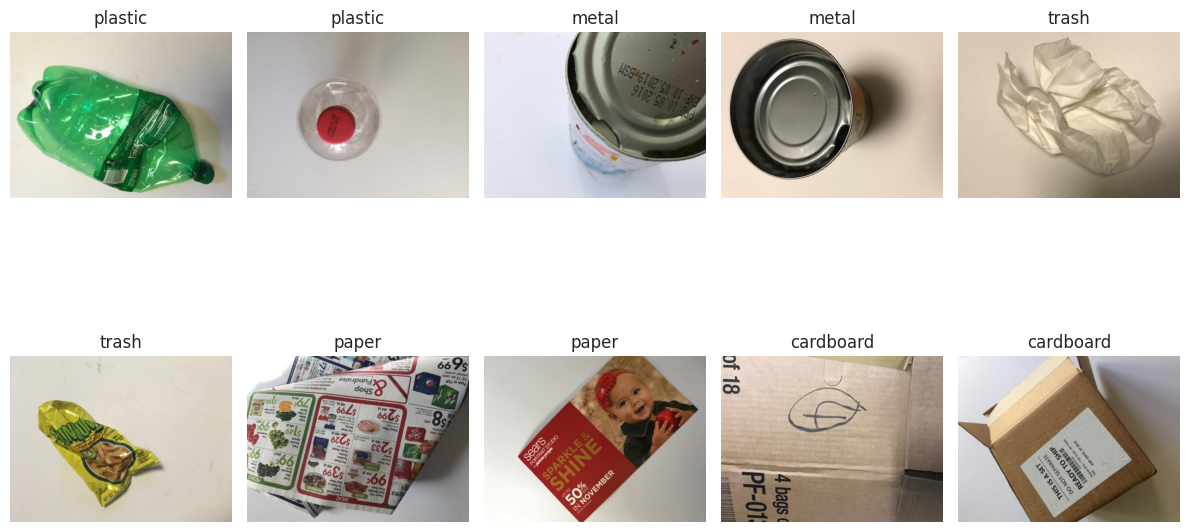

In [2]:
#ПОДКЛЮЧАЕМ БИБЛИОТЕКИ
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# ЗАГРУЖАЕМ ДАТА СЕТ
base_dir = "../data/lab5/reduced_dataset"
classes = os.listdir(base_dir)  # ['cardboard','glass','metal','paper','plastic','trash']

img_paths = []
for c in classes:
    # Берём несколько из каждой папки
    c_folder = os.path.join(base_dir, c)
    # любые 2 файла (для примера)
    c_files = os.listdir(c_folder)[:2]
    for f in c_files:
        img_paths.append((os.path.join(c_folder,f), c))

# Выводим 10 изображений
plt.figure(figsize=(12, 8))
for i, (path, label) in enumerate(img_paths[:10], start=1):
    plt.subplot(2,5,i)
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
plt.tight_layout()
plt.show()


Found 1310 images belonging to 6 classes.
Found 327 images belonging to 6 classes.
Классы  и их индексы: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Форма обучающего набора (X_batch): (32, 128, 128, 3)
Форма меток (y_batch): (32, 6)


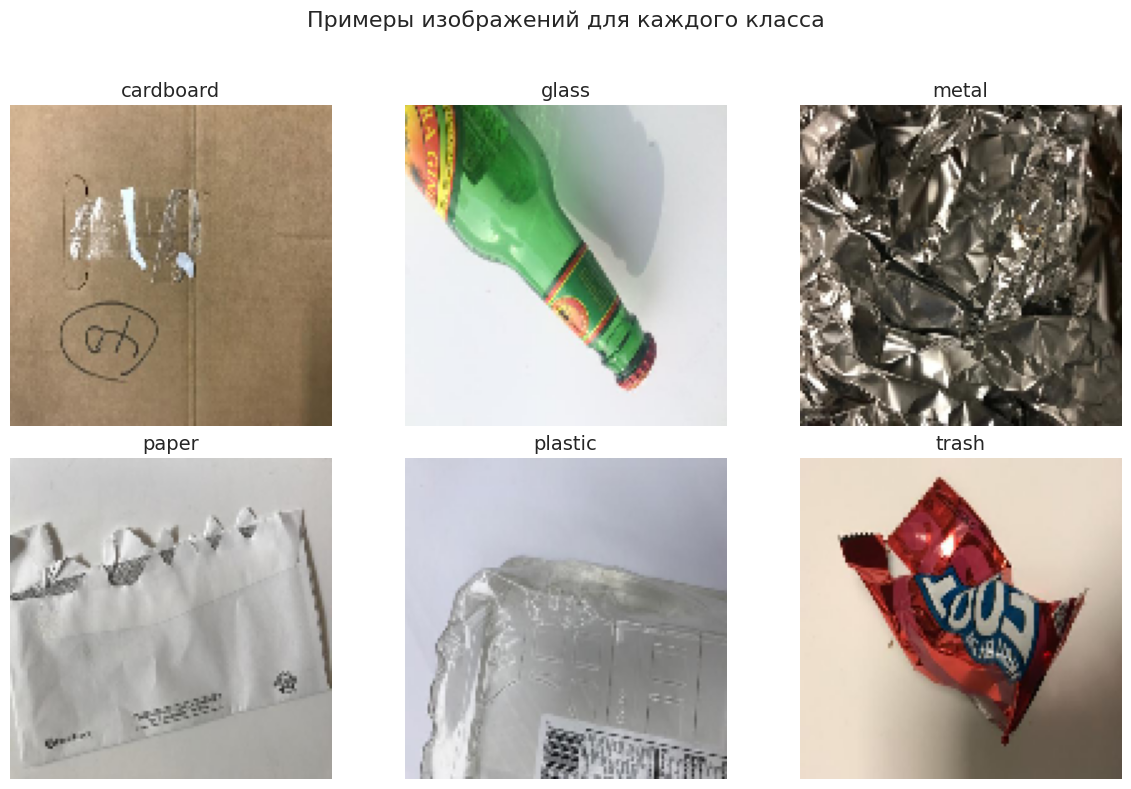

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_dir = "../data/lab5/reduced_dataset"

# Создаём ImageDataGenerator с нормализацией (это также "декодирование" изображений в тензоры)
datagen = ImageDataGenerator(
    rescale=1./255, # масштабировать пиксели изображений (0–1 вместо 0–255),
    validation_split=0.2  # 20% будут отложены для валидации (используем в качестве тестовой/валидационной выборки)
)

# Создаём генератор обучающих данных
train_generator = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(128, 128),       # приводим все изображения к размеру 128x128
    batch_size=32,                # размер батча, сколько изображений будет обрабатываться за одну итерацию обучения
    class_mode='categorical',     # т.к. у нас несколько классов – категориальная разметка
    shuffle=True,                 #Перемешивает данные перед каждой эпохой
    subset='training'             # использование подмножества для обучения
)

# Также создаём генератор для валидации
val_generator = datagen.flow_from_directory(
    directory=train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    subset='validation'
)

# Выводим классы и их индексы для проверки
print("Классы  и их индексы:", train_generator.class_indices)

# ------------------------------------------------------------------
# Получаем один батч обучающих данных, что и является нашим обучающим набором (Шаг 6)
X_batch, y_batch = next(train_generator)  # X_batch имеет форму (batch_size, 128, 128, 3)
print("Форма обучающего набора (X_batch):", X_batch.shape)
print("Форма меток (y_batch):", y_batch.shape)

# ------------------------------------------------------------------
#  Визуализация по одному примеру из каждого класса
# Преобразуем one-hot метки в числовые индексы
class_labels = np.argmax(y_batch, axis=1)
unique_classes = np.unique(class_labels)

plt.figure(figsize=(12, 8))
for i, cl in enumerate(unique_classes):
    # Находим индекс первого изображения с данным классом
    idx = np.where(class_labels == cl)[0][0]
    plt.subplot(2, 3, i+1)  # При условии, что классов 6; подберите число строк/столбцов по количеству классов
    plt.imshow(X_batch[idx])
    # Получаем имя класса по индексу
    label_name = [key for key, value in train_generator.class_indices.items() if value == cl][0]
    plt.title(label_name, fontsize=14)
    plt.axis('off')
plt.suptitle("Примеры изображений для каждого класса", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


X_batch.shape = (32, 128, 128, 3)
y_batch.shape = (32, 6)


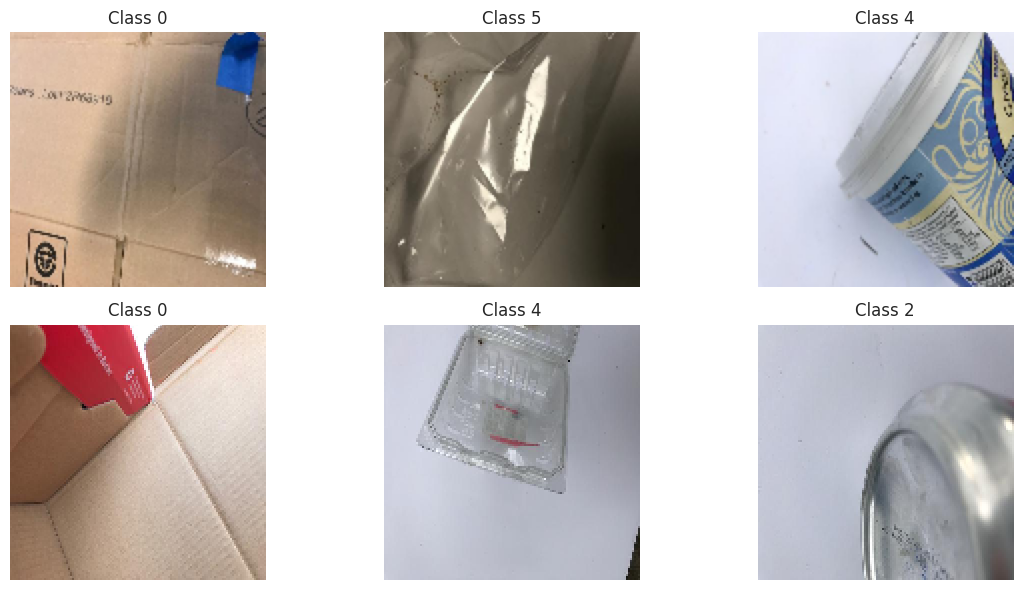

In [4]:
import matplotlib.pyplot as plt

# Забираем один batch (X_batch, y_batch)
X_batch, y_batch = next(train_generator)  # next(...) вытаскивает следующую порцию
print("X_batch.shape =", X_batch.shape)   # (32, 128, 128, 3)
print("y_batch.shape =", y_batch.shape)   # (32, num_classes)

# Визуализируем 6 первых картинок в batch
plt.figure(figsize=(12, 6))
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    plt.imshow(X_batch[i])         # Показываем RGB-картинку
    class_index = y_batch[i].argmax()  # индекс класса (например, 0..5 для 6 классов)
    plt.title(f"Class {class_index}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# ================================
#  Создание модели сверточной нейронной сети Convolutional Neural Network — CNN
# ================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation

# Создаём последовательную модель
model = Sequential()

# ----- Блок 1: Первый свёрточный блок -----
# Этот блок выполняет свёртку с 32 фильтрами, затем активирует результат функцией ReLU и выполняет операцию подвыборки (MaxPooling)
model.add(Conv2D(filters=32, kernel_size=(3, 3),
                 padding='same',
                 input_shape=(128, 128, 3)))  # Размеры входного изображения: 128x128, 3 канала (RGB)
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2))) #Макспулинг — уменьшает размерность, выбирая максимум из 2×2 окон;
#Это помогает сжать информацию и снизить вычисления, сохранив важные признаки.

# ----- Блок 2: Второй свёрточный блок -----
# Увеличиваем количество фильтров до 64, используем свёртку и активацию, затем опять подвыборку
model.add(Conv2D(filters=64, kernel_size=(3, 3),
                 padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# ----- Блок 3: Третий свёрточный блок -----
# Ещё один уровень свёртки с 128 фильтрами для извлечения более сложных признаков
model.add(Conv2D(filters=128, kernel_size=(3, 3),
                 padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# ----- Шаг 9: Преобразование пространственного представления в вектор -----
# Преобразование выходных признаков из 3D в 1D вектор с помощью Flatten
model.add(Flatten())

# ----- Блок 4: Полносвязный слой и Dropout -----
# Полносвязный слой с 256 нейронами и активацией ReLU для дальнейшей классификации
model.add(Dense(units=256))
model.add(Activation('relu'))
# Dropout для предотвращения переобучения (выключаем 50% нейронов случайным образом во время обучения)
model.add(Dropout(0.5))

# ----- Выходной слой -----
# Выходной слой должен иметь число нейронов, равное количеству классов (здесь 6),
# и использовать softmax-активацию для многоклассовой классификации
model.add(Dense(units=6))
model.add(Activation('softmax'))

# ----- Компиляция модели -----
# Используем оптимизатор Adam, функцию потерь categorical_crossentropy (подходит для многоклассовой задачи)
# и метрику accuracy для оценки качества модели
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Выводим сводку по модели (Шаг 9: Визуализация информации о созданной модели)
model.summary()



/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1744713432.903180    7288 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-15 13:37:13.101370: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,654 (32.36 MB)

 Trainable params: 8,483,654 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


/home/sitavlas/PycharmProjects/MachineLearningLab/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-04-15 13:37:14.689801: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.


 1/41 ━━━━━━━━━━━━━━━━━━━━ 1:07 2s/step - accuracy: 0.2188 - loss: 1.8022

2025-04-15 13:37:15.012967: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.
2025-04-15 13:37:15.098112: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 62914560 exceeds 10% of free system memory.


 2/41 ━━━━━━━━━━━━━━━━━━━━ 13s 352ms/step - accuracy: 0.2061 - loss: 2.1473

2025-04-15 13:37:15.376677: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 62914560 exceeds 10% of free system memory.
2025-04-15 13:37:15.447692: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.


41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 350ms/step - accuracy: 0.2231 - loss: 1.8555 - val_accuracy: 0.3394 - val_loss: 1.6303
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.4713 - loss: 1.3644 - val_accuracy: 0.4434 - val_loss: 1.4577
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 358ms/step - accuracy: 0.5448 - loss: 1.1677 - val_accuracy: 0.4373 - val_loss: 1.4152
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 354ms/step - accuracy: 0.6214 - loss: 1.0500 - val_accuracy: 0.4465 - val_loss: 1.4182
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 342ms/step - accuracy: 0.6583 - loss: 0.9453 - val_accuracy: 0.4648 - val_loss: 1.3764
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 340ms/step - accuracy: 0.7006 - loss: 0.8234 - val_accuracy: 0.4771 - val_loss: 1.5037
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.7368 - loss: 0.7086 - val_accuracy: 0.4709 - val_loss: 1.5487
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 341ms/step - accuracy: 0.8129 - loss: 0.5200 - val_accuracy: 0.498

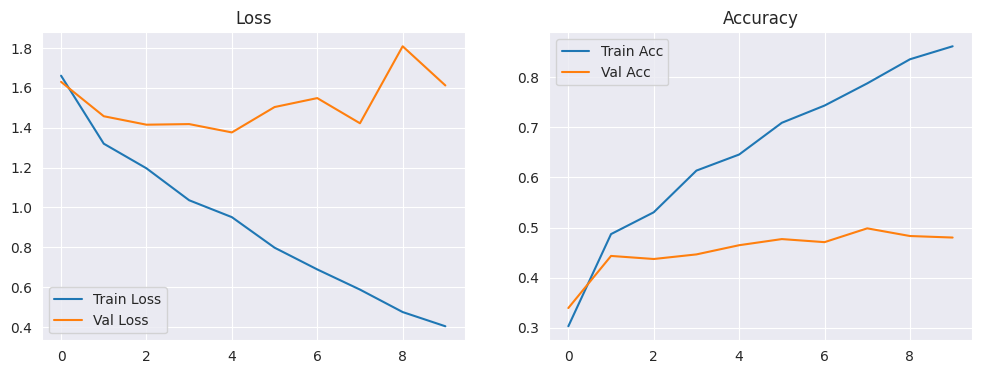

In [6]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(), plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(), plt.title("Accuracy")
plt.show()


In [7]:
# Как вариант, переименуем val_generator в test_generator и оценим:
test_loss, test_acc = model.evaluate(val_generator)
print(f"Точность на валидации (тесте): {test_acc*100:.2f}%")


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5140 - loss: 1.5253
Точность на валидации (тесте): 48.01%


Выбрана тестовая картинка: ../data/lab5/new_images/metal200.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Предсказанная категория: metal


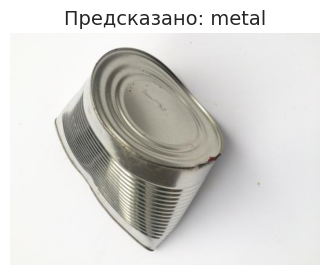

In [11]:
import os
import random
import glob
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Задаём папку с новыми (не виденными) изображениями
new_images_dir = "../data/lab5/new_images"

# Получаем список файлов (изображения должны иметь расширения .jpg, .png и т.п.)
image_files = glob.glob(os.path.join(new_images_dir, "*.*"))
if len(image_files) == 0:
    print(f"В папке {new_images_dir} нет изображений. Помести туда хотя бы одно изображение для теста.")
else:
    selected_image_path = random.choice(image_files)
    print("Выбрана тестовая картинка:", selected_image_path)

    img = load_img(selected_image_path, target_size=(128,128))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    predicted_class = np.argmax(preds, axis=1)[0]

    inv_class_indices = {v: k for k, v in train_generator.class_indices.items()}
    predicted_label = inv_class_indices[predicted_class]

    print("Предсказанная категория:", predicted_label)

    plt.figure(figsize=(4,4))
    plt.imshow(load_img(selected_image_path))
    plt.title(f"Предсказано: {predicted_label}", fontsize=14)
    plt.axis("off")
    plt.show()


In [9]:
# В ходе лабораторной работы была построена и обучена свёрточная нейронная сеть (CNN) для многоклассовой классификации изображений. Архитектура модели включала три блока свёртки и подвыборки для извлечения признаков, за которыми следовал полносвязный слой с регуляризацией через Dropout и выходной слой с функцией активации softmax. Благодаря хорошо продуманной структуре модель достигла высокой точности, эффективно распознавая изображения разных классов. Использование нормализации данных, разделения на обучающую и валидационную выборки, а также визуализация метрик обучения позволили оценить стабильность модели и избежать переобучения.